# Preliminaries

In this notebook, we are going to simulate a 2-Qubit-Coupler and drive it with a new gate scheme. You will:

(1) derive the effective Hamiltonian of the system,

(2) extract its effective description, which allows you to predict the parameters of the gate protocol

(3) numerically simulate the gate and check its fidelity

Before we start: clone the github project with the needed python packages and data.

We propose: run the following cell to clone it and move into the repo folder

Let's install the required packages:

In [1]:
pip install numpy scipy matplotlib sympy xarray h5netcdf qutip tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys

# Remove the corrupted/cached modules
modules_to_remove = [m for m in sys.modules.keys() if 'helper_function' in m or 'Floquet_perturbation_theory' in m]
for m in modules_to_remove:
    del sys.modules[m]

from Floquet_perturbation_theory import *
from qutip import *
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import xarray as xr
from scipy.optimize import fsolve
from tqdm.notebook import tqdm
from helper_function import *

from sympy.physics.quantum import Dagger
from sympy.physics.quantum.boson import BosonOp

Here, we start with a transmon-coupler-transmon architecture Hamiltonian (see picture)
$$
\begin{gathered}
    H = \sum_{i=1,2} 4 E_{C_i} n_i^2 - E_{J_i} \cos(\phi_i) + 4 E_{C_c} n_c^2 - E_{J_\Sigma} \sqrt{\cos^2(\phi_\text{ext})+d^2\sin(\phi_\text{ext})^2} \cos(\phi_c) \\
    + g_{1c} n_1 n_c + g_{2c} n_2 n_c + g_{12} n_1 n_2
\end{gathered}
$$
\
with $d=\frac{E_{Jc_1}-E_{Jc_2}}{E_{Jc_1}+E_{Jc_2}}$ and $E_{J_\Sigma}=E_{Jc_1}+E_{Jc_2}$

Aiming for a parametric two-qubit gate, we implement a small periodic modulation of external flux, i.e., $\phi_{\text{ext}}=\delta \cos(\omega_d t)$. By choosing the frequency
$$
\omega_d \approx \omega_2 - \omega_1
$$,
we aim for a iswap-type process between two qubit states. However, driven quantum systems typically experience "frequency detunings" (aka Stark shifts), which change the frequency at which we should drive. We are going to employ an *effective* framework to predict the correct drive frequency and the Rabi rate of the gate.

Before we simulate anything, let's rewrite the Hamiltonian above using sympy expansions to get a form that is easily manipulateable.

<img src="https://github.com/qubitsfan/TransmonCouplerSimulation/blob/main/Figure/CircuitDiagram.png?raw=1" width="800">

# Warm-Up: Effective Form of the cQED Hamiltonian

Goal: Transform the full-circuit cQED-Hamiltonian to an qubit-like description (two qubits and a frequency-tunable coupler).

We will later see that a clear separation in static and time-modulated parts is the starting point to derive the effective Hamiltonian via perturbation theory.

We start from Taylor expansions of the full coupler-transmon-Hamiltonian:

In [3]:
phi_ext = sp.symbols("\\phi_{ext}")
EJSigma = sp.symbols("E_{J\\Sigma}")
d = sp.symbols("d")

squid = EJSigma * sp.sqrt((sp.cos(phi_ext)) ** 2 + d**2 * (sp.sin(phi_ext)) ** 2)
squid

E_{J\Sigma}*sqrt(d**2*sin(\phi_{ext})**2 + cos(\phi_{ext})**2)

We consider the simplest case where the flux bias point is at symmetry point, i.e., $\phi_{ext}=\delta \cos(\omega_d t)$. When the bias is not 0, there will be multiple frequencies of the drive.

We replace the external flux of squid Hamiltonian by a perodic modulation fuction:

In [4]:
delta = sp.symbols("\\delta")
wd = sp.symbols("\\omega_{d}")
t = sp.symbols("t")
phi_0 =  sp.symbols("\\phi_{0}")
gamma = sp.symbols("\\gamma")

squid_modulated = squid.subs({phi_ext: phi_0 + delta * sp.cos(wd * t)})
squid_modulated

E_{J\Sigma}*sqrt(d**2*sin(\delta*cos(\omega_{d}*t) + \phi_{0})**2 + cos(\delta*cos(\omega_{d}*t) + \phi_{0})**2)

Then we can do Taylor expansion and collect the terms in the power of small modulation $\delta$

Use $\gamma=\sqrt{d^2\sin^2(\phi_0)+\cos^2(\phi_0)}$

In [5]:

ejc_expansion = squid_modulated.series(delta, 0, 3).removeO()
ejc_expansion = sp.factor(ejc_expansion)
ejc_expansion = ejc_expansion.subs({sp.sqrt(d**2 * sp.sin(phi_0)**2 + sp.cos(phi_0)**2): gamma})

ejc_simplified = sp.fu(ejc_expansion)
ejc_collected = sp.collect(ejc_simplified.expand(), delta * sp.cos(wd * t))

#compare to the simpler case, where the bias is zero
print("bias zero case:")
display(ejc_collected.subs({gamma: sp.sqrt(d**2 * sp.sin(phi_0)**2 + sp.cos(phi_0)**2)}).subs({phi_0: 0}))
print("general case with bias: ")
display(ejc_collected)
print("ignoring factors")
sp.collect(clean_expr(ejc_collected.subs({EJSigma: 1}).subs({gamma: 1})), delta * sp.cos(wd * t))

bias zero case:


E_{J\Sigma} + \delta**2*(E_{J\Sigma}*d**2/2 - E_{J\Sigma}/2)*cos(\omega_{d}*t)**2

general case with bias: 


E_{J\Sigma}*d**4*sin(\phi_{0})**4/\gamma**3 + 2*E_{J\Sigma}*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 + E_{J\Sigma}*cos(\phi_{0})**4/\gamma**3 + \delta**2*(-E_{J\Sigma}*d**4*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*cos(\phi_{0})**4/(2*\gamma**3) - E_{J\Sigma}*cos(\phi_{0})**4/(2*\gamma**3))*cos(\omega_{d}*t)**2 + \delta*(E_{J\Sigma}*d**4*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 - E_{J\Sigma}*d**2*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 + E_{J\Sigma}*d**2*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3 - E_{J\Sigma}*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3)*cos(\omega_{d}*t)

ignoring factors


\delta**2*(-d**4*sin(\phi_{0})**4/2 + d**2*sin(\phi_{0})**4/2 + d**2*cos(\phi_{0})**4/2 - cos(\phi_{0})**4/2)*cos(\omega_{d}*t)**2 + \delta*(d**4*sin(\phi_{0})**3*cos(\phi_{0}) - d**2*sin(\phi_{0})**3*cos(\phi_{0}) + d**2*sin(\phi_{0})*cos(\phi_{0})**3 - sin(\phi_{0})*cos(\phi_{0})**3)*cos(\omega_{d}*t) + d**4*sin(\phi_{0})**4 + d**2*(1 - cos(4*\phi_{0}))/4 + cos(\phi_{0})**4

By ignoring the energy shift of the Hamiltonian, it looks like
$$
\begin{gathered}
    H = \sum_{i=1,2} 4 E_{C_i} n_i^2 - E_{J_i} \cos(\phi_i) + 4 E_{C_c} n_c^2 - E_{J_\Sigma} \cos(\phi_c) \left(1+\frac{d^2-1}{2}\cos(\omega_d t)^2\right) \\
    + g_{1c} n_1 n_c + g_{2c} n_2 n_c + g_{12} n_1 n_2
\end{gathered}
$$

With $\phi_0\neq0$ we get a more complicated term 
$$
\begin{gathered}
    H = \sum_{i=1,2} 4 E_{C_i} n_i^2 - E_{J_i} \cos(\phi_i) + 4 E_{C_c} n_c^2 - E_{J_\Sigma} \cos(\phi_c) \left(1+\frac{d^2-1}{2}\cos(\omega_d t)^2\right) \\
    + g_{1c} n_1 n_c + g_{2c} n_2 n_c + g_{12} n_1 n_2 TODO
\end{gathered}
$$

Now we want to implement the second quantization to really write the Hamiltonian in terms of creation and annihilation operators.

In [6]:
# The definitions of non-commuting operators should be different from trivial variables.
# Otherwise, SymPy will treat them as commuting variables and give wrong results when we do algebraic manipulation.

a1 = BosonOp("a_1")
ad1 = Dagger(a1)
a2 = BosonOp("a_2")
ad2 = Dagger(a2)
ac = BosonOp("a_c")
adc = Dagger(ac)

# Define the symbols for the parameters in the Hamiltonian
EC1, EC2, ECc = sp.symbols("E_{C1}, E_{C2}, E_{Cc}")
EJ1, EJ2, EJc = sp.symbols("E_{J1}, E_{J2}, E_{Jc}")
g1c, g2c, g12 = sp.symbols("g_{1c}, g_{2c}, g_{12}")

# Let's first keep the charge and phase operators, and later we can express them in terms of ladder operators if needed.
n1, n2, nc = sp.symbols("n_1, n_2, n_c")
phi1, phi2, phic = sp.symbols("\\phi_1, \\phi_2, \\phi_c")

# Thus the coupled Hamiltonian can be written as:
Hamiltonian = (
    4 * EC1 * n1**2
    - EJ1 * sp.cos(phi1)
    + 4 * EC2 * n2**2
    - EJ2 * sp.cos(phi2)
    + 4 * ECc * nc**2
    - EJc * sp.cos(phic)
    + g1c * n1 * nc
    + g2c * n2 * nc
    + g12 * n1 * n2
)
Hamiltonian

4*E_{C1}*n_1**2 + 4*E_{C2}*n_2**2 + 4*E_{Cc}*n_c**2 - E_{J1}*cos(\phi_1) - E_{J2}*cos(\phi_2) - E_{Jc}*cos(\phi_c) + g_{12}*n_1*n_2 + g_{1c}*n_1*n_c + g_{2c}*n_2*n_c

Now we insert the expression of modulated Josephson energy of the coupler

In [7]:
Hamiltonian_expanded = Hamiltonian.subs({EJc: ejc_collected})
Hamiltonian_expanded

4*E_{C1}*n_1**2 + 4*E_{C2}*n_2**2 + 4*E_{Cc}*n_c**2 - E_{J1}*cos(\phi_1) - E_{J2}*cos(\phi_2) + g_{12}*n_1*n_2 + g_{1c}*n_1*n_c + g_{2c}*n_2*n_c - (E_{J\Sigma}*d**4*sin(\phi_{0})**4/\gamma**3 + 2*E_{J\Sigma}*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 + E_{J\Sigma}*cos(\phi_{0})**4/\gamma**3 + \delta**2*(-E_{J\Sigma}*d**4*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*cos(\phi_{0})**4/(2*\gamma**3) - E_{J\Sigma}*cos(\phi_{0})**4/(2*\gamma**3))*cos(\omega_{d}*t)**2 + \delta*(E_{J\Sigma}*d**4*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 - E_{J\Sigma}*d**2*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 + E_{J\Sigma}*d**2*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3 - E_{J\Sigma}*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3)*cos(\omega_{d}*t))*cos(\phi_c)

We apply the Taylor expansions of the cos-terms to address the anharmonicity of the each transmon

In [8]:
Hamiltonian_cos_expanded = Hamiltonian_expanded.series(phi1, 0, 5).removeO().series(phi2, 0, 5).removeO().series(phic, 0, 5).removeO()
Hamiltonian_cos_expanded

4*E_{C1}*n_1**2 + 4*E_{C2}*n_2**2 + 4*E_{Cc}*n_c**2 - E_{J1}*\phi_1**4/24 + E_{J1}*\phi_1**2/2 - E_{J1} - E_{J2}*\phi_2**4/24 + E_{J2}*\phi_2**2/2 - E_{J2} - E_{J\Sigma}*d**4*sin(\phi_{0})**4/\gamma**3 - 2*E_{J\Sigma}*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 - E_{J\Sigma}*cos(\phi_{0})**4/\gamma**3 - \delta**2*(-E_{J\Sigma}*d**4*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*sin(\phi_{0})**4/(2*\gamma**3) + E_{J\Sigma}*d**2*cos(\phi_{0})**4/(2*\gamma**3) - E_{J\Sigma}*cos(\phi_{0})**4/(2*\gamma**3))*cos(\omega_{d}*t)**2 - \delta*(E_{J\Sigma}*d**4*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 - E_{J\Sigma}*d**2*sin(\phi_{0})**3*cos(\phi_{0})/\gamma**3 + E_{J\Sigma}*d**2*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3 - E_{J\Sigma}*sin(\phi_{0})*cos(\phi_{0})**3/\gamma**3)*cos(\omega_{d}*t) + \phi_c**4*(-E_{J\Sigma}*d**4*sin(\phi_{0})**4/(24*\gamma**3) - E_{J\Sigma}*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/(12*\gamma**3) - E_{J\Sigma}*cos(\phi_{0})**4/(24*\gamma**3) - \delta**2*(-E_{J\Sigma

Substituting the ladder operator expressions with
$$
\begin{align}
\phi = \left(\frac{2E_C}{E_J}\right)^{\frac{1}{4}}(a+a^\dagger)\\
n = i\left(\frac{2E_J}{32E_C}\right)^{\frac{1}{4}}(a^\dagger-a)
\end{align}
$$
The resulting expression is then expanded and put into normal ordering.

In [9]:
# Now substitute the ladder operator expressions into the expanded Hamiltonian
Hamiltonian_substituted= SecondQuantizedForm(Hamiltonian_cos_expanded)

# Get the energy offset by substituting all ladder operators to zero (vacuum expectation value)
print("computing the constant energy of the hamiltonian and removing it")
constant = Hamiltonian_substituted.subs(
    {a1: 0, a2: 0, ac: 0, ad1: 0, ad2: 0, adc: 0}
)

# Subtract the constant from the Hamiltonian to set the ground state energy to zero
Hamiltonian_substituted = Hamiltonian_substituted - constant

# Collect terms in the order of physcial parameters for better readability
Hamiltonian_expanded_sort = sp.collect(
    Hamiltonian_substituted, [delta * sp.cos(wd * t), g12, g1c, g2c]
)

#for better readability we substitte a_dag * a for the number operator
N1, N2, Nc = sp.symbols("N_1, N_2, N_c")

Hamiltonian_expanded_sort = Hamiltonian_expanded_sort.subs(
    {
        Dagger(a1) * a1: N1,
        Dagger(a2) * a2: N2,
        Dagger(ac) * ac: Nc,
    }
)
print("Hardcore approximated Hamiltonian (cos developed and a^2 upwards neglected)")
Hamiltonian_expanded_hardcore = HardCore(Hamiltonian_expanded_sort, a1, a2, ac)
display(Hamiltonian_expanded_hardcore)

print("Hamiltonian with no bias")
display(Hamiltonian_expanded_hardcore.subs({gamma: 1}).subs({phi_0: 0}))


computing the constant energy of the hamiltonian and removing it
Hardcore approximated Hamiltonian (cos developed and a^2 upwards neglected)


-E_{C1}*N_1**2/2 - E_{C1}*N_1 - E_{C2}*N_2**2/2 - E_{C2}*N_2 - E_{Cc}*N_c**2*d**4*sin(\phi_{0})**4/(2*\gamma**3) - E_{Cc}*N_c**2*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 - E_{Cc}*N_c**2*cos(\phi_{0})**4/(2*\gamma**3) - E_{Cc}*N_c*d**4*sin(\phi_{0})**4/\gamma**3 - 2*E_{Cc}*N_c*d**2*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 - E_{Cc}*N_c*cos(\phi_{0})**4/\gamma**3 + 2*sqrt(2)*N_1*sqrt(E_{C1}*E_{J1}) + 2*sqrt(2)*N_2*sqrt(E_{C2}*E_{J2}) + sqrt(2)*N_c*sqrt(E_{Cc}*E_{J\Sigma}) + sqrt(2)*N_c*d**4*sqrt(E_{Cc}*E_{J\Sigma})*sin(\phi_{0})**4/\gamma**3 + 2*sqrt(2)*N_c*d**2*sqrt(E_{Cc}*E_{J\Sigma})*sin(\phi_{0})**2*cos(\phi_{0})**2/\gamma**3 + sqrt(2)*N_c*sqrt(E_{Cc}*E_{J\Sigma})*cos(\phi_{0})**4/\gamma**3 + \delta**2*(E_{Cc}*N_c**2*d**4*sin(\phi_{0})**4/(4*\gamma**3) - E_{Cc}*N_c**2*d**2*sin(\phi_{0})**4/(4*\gamma**3) - E_{Cc}*N_c**2*d**2*cos(\phi_{0})**4/(4*\gamma**3) + E_{Cc}*N_c**2*cos(\phi_{0})**4/(4*\gamma**3) + E_{Cc}*N_c*d**4*sin(\phi_{0})**4/(2*\gamma**3) - E_{Cc}*N_c*d**2*sin(\ph

Hamiltonian with no bias


-E_{C1}*N_1**2/2 - E_{C1}*N_1 - E_{C2}*N_2**2/2 - E_{C2}*N_2 - E_{Cc}*N_c**2/2 - E_{Cc}*N_c + 2*sqrt(2)*N_1*sqrt(E_{C1}*E_{J1}) + 2*sqrt(2)*N_2*sqrt(E_{C2}*E_{J2}) + 2*sqrt(2)*N_c*sqrt(E_{Cc}*E_{J\Sigma}) + \delta**2*(-E_{Cc}*N_c**2*d**2/4 + E_{Cc}*N_c**2/4 - E_{Cc}*N_c*d**2/2 + E_{Cc}*N_c/2 + sqrt(2)*N_c*d**2*sqrt(E_{Cc}*E_{J\Sigma})/2 - sqrt(2)*N_c*sqrt(E_{Cc}*E_{J\Sigma})/2)*cos(\omega_{d}*t)**2 + g_{12}*(-sqrt(2)*(E_{J1}*E_{J2})**(1/4)*Dagger(a_1)*Dagger(a_2)/(8*(E_{C1}*E_{C2})**(1/4)) + sqrt(2)*(E_{J1}*E_{J2})**(1/4)*Dagger(a_1)*a_2/(8*(E_{C1}*E_{C2})**(1/4)) - sqrt(2)*(E_{J1}*E_{J2})**(1/4)*a_1*a_2/(8*(E_{C1}*E_{C2})**(1/4)) + sqrt(2)*(E_{J1}*E_{J2})**(1/4)*Dagger(a_2)*a_1/(8*(E_{C1}*E_{C2})**(1/4))) + g_{1c}*(-sqrt(2)*(E_{J1}*E_{J\Sigma})**(1/4)*Dagger(a_1)*Dagger(a_c)/(8*(E_{C1}*E_{Cc})**(1/4)) + sqrt(2)*(E_{J1}*E_{J\Sigma})**(1/4)*Dagger(a_1)*a_c/(8*(E_{C1}*E_{Cc})**(1/4)) - sqrt(2)*(E_{J1}*E_{J\Sigma})**(1/4)*a_1*a_c/(8*(E_{C1}*E_{Cc})**(1/4)) + sqrt(2)*(E_{J1}*E_{J\Sigma})**

For a more intuitive understanding of this Hamiltonian, we would like to apply the HardCore approximation (remove the off-diagonal terms in each of the single bosonnic modes, which corresponds to the hard-core boson limit, where each mode can only have 0 or 1 excitation)

In [10]:

# Print the static qubit, coupler as well as static coupling of the Hamiltonian by substituting the interaction terms to zero.
print("The first qubit part of the Hamiltonian is: ")
display(
    sp.collect(
        clean_expr(Hamiltonian_expanded_hardcore.subs({N2: 0, Nc: 0, g12: 0, g1c: 0, g2c: 0})), [N1]
    )
)
print("The second qubit part of the Hamiltonian is: ")
display(
    sp.collect(
        clean_expr(Hamiltonian_expanded_hardcore.subs({N1:0, Nc:0, g12:0, g1c:0, g2c:0})), [N2]
    )
)
print("The coupler part of the Hamiltonian is (note the separation in time dependant coupling and normal transmon behaviour): ")
display(
    sp.collect(
        sp.collect(
            clean_expr(Hamiltonian_expanded_hardcore.subs({N1:0, N2:0, g12:0, g1c:0, g2c:0})).expand(),
              delta * sp.cos(wd * t)
        ), [Nc]
    )
)

print("The coupling part of the Hamiltonian is: ")
display(
    sp.simplify(
        sp.collect(
            Hamiltonian_expanded_hardcore.subs({N1: 0, N2: 0, Nc: 0, g1c: 0, g2c: 0}),
            [g12],
        )
    )
    + sp.simplify(
        sp.collect(
            Hamiltonian_expanded_hardcore.subs({N1: 0, N2: 0, Nc: 0, g12: 0, g2c: 0}),
            [g1c],
        )
    )
    + sp.simplify(
        sp.collect(
            Hamiltonian_expanded_hardcore.subs({N1: 0, N2: 0, Nc: 0, g12: 0, g1c: 0}),
            [g2c],
        )
    )
)

The first qubit part of the Hamiltonian is: 


N_1*(-E_{C1}*N_1 - 2*E_{C1} + 4*sqrt(2)*sqrt(E_{C1}*E_{J1}))/2

The second qubit part of the Hamiltonian is: 


N_2*(-E_{C2}*N_2 - 2*E_{C2} + 4*sqrt(2)*sqrt(E_{C2}*E_{J2}))/2

The coupler part of the Hamiltonian is (note the separation in time dependant coupling and normal transmon behaviour): 


N_c**2*(-E_{Cc}*d**4*sin(\phi_{0})**4/(2*\gamma**3) + E_{Cc}*d**2*cos(4*\phi_{0})/(8*\gamma**3) - E_{Cc}*d**2/(8*\gamma**3) - E_{Cc}*cos(\phi_{0})**4/(2*\gamma**3)) + N_c*(-E_{Cc}*d**4*sin(\phi_{0})**4/\gamma**3 + E_{Cc}*d**2*cos(4*\phi_{0})/(4*\gamma**3) - E_{Cc}*d**2/(4*\gamma**3) - E_{Cc}*cos(\phi_{0})**4/\gamma**3 + sqrt(2)*sqrt(E_{Cc}*E_{J\Sigma}) + sqrt(2)*d**4*sqrt(E_{Cc}*E_{J\Sigma})*sin(\phi_{0})**4/\gamma**3 - sqrt(2)*d**2*sqrt(E_{Cc}*E_{J\Sigma})*cos(4*\phi_{0})/(4*\gamma**3) + sqrt(2)*d**2*sqrt(E_{Cc}*E_{J\Sigma})/(4*\gamma**3) + sqrt(2)*sqrt(E_{Cc}*E_{J\Sigma})*cos(\phi_{0})**4/\gamma**3) + \delta**2*(N_c**2*(E_{Cc}*d**4*sin(\phi_{0})**4/(4*\gamma**3) - E_{Cc}*d**2*sin(\phi_{0})**4/(4*\gamma**3) - E_{Cc}*d**2*cos(\phi_{0})**4/(4*\gamma**3) + E_{Cc}*cos(\phi_{0})**4/(4*\gamma**3)) + N_c*(E_{Cc}*d**4*sin(\phi_{0})**4/(2*\gamma**3) - E_{Cc}*d**2*sin(\phi_{0})**4/(2*\gamma**3) - E_{Cc}*d**2*cos(\phi_{0})**4/(2*\gamma**3) + E_{Cc}*cos(\phi_{0})**4/(2*\gamma**3) - sqrt(2)*d**4*s

The coupling part of the Hamiltonian is: 


sqrt(2)*g_{12}*(E_{J1}*E_{J2})**(1/4)*(-Dagger(a_1)*Dagger(a_2) + Dagger(a_1)*a_2 - a_1*a_2 + Dagger(a_2)*a_1)/(8*(E_{C1}*E_{C2})**(1/4)) + sqrt(2)*g_{1c}*(E_{J1}*E_{J\Sigma})**(1/4)*(-Dagger(a_1)*Dagger(a_c) + Dagger(a_1)*a_c - a_1*a_c + Dagger(a_c)*a_1)/(8*(E_{C1}*E_{Cc})**(1/4)) + sqrt(2)*g_{2c}*(E_{J2}*E_{J\Sigma})**(1/4)*(-Dagger(a_2)*Dagger(a_c) + Dagger(a_2)*a_c - a_2*a_c + Dagger(a_c)*a_2)/(8*(E_{C2}*E_{Cc})**(1/4))

Remark: Though here we only include the symmetric case, one can easily assume a nonzero bias point and omit the changes in the code to compute higher order contributions.

# Initial Numerical Implementation of the System

After knowing the the explicit form of the Hamiltonian, let's implement it for numerical simulations. To eventually perform a gate, we need to know: (a) the drive frequency and (b) the gate time (corresponding to the Rabi rate of the swap).
To predict these values precisely, we will numerically compute an *effective Hamiltonian* via perturbation theory. To make use of the framework that follows the Hamiltonian needs to be split as follows:
$$
\begin{gathered}
    H (t) = \sum_i E_i |i\rangle\langle i| + V(t)\\
\end{gathered}
$$
where $ \sum_i E_i |i\rangle\langle i|$ is completely diagonal (describing the system without interactions) and all interactions and time depency needs to be in the perturbative part $V(t)=V_0+V_1e^{i\omega_d t}+h.c.$.

First, we construct the time-independent part $E$:

In [11]:
# we use the typical operators to indicate the non-zero matrix elements between the states of interest.
dim_q1 = 3
dim_q2 = 3
dim_c = 3

w1, w2, wc, alpha1, alpha2, alphac, g1c, g2c, g12, c1, c2 = sp.symbols(
    "\\omega_1, \\omega_2, \\omega_c, \\alpha_1, \\alpha_2, \\alpha_c, g_{1c}, g_{2c}, g_{12}, c_{1}, c_{2}", 
    real=True,
)

a_q1 = tensor(destroy(dim_q1), qeye(dim_c), qeye(dim_q2))
a_q2 = tensor(qeye(dim_q1), qeye(dim_c), destroy(dim_q2))
a_qc = tensor(qeye(dim_q1), destroy(dim_c), qeye(dim_q2))

# sowohl die harmonische als auch die erste anharmonische Ordnung ist eine Funktion von n, also diagonal 
# a†a†aa = n(n-1) np.diag() liefert eine Liste der 27 Diagonaleinträge
E = np.diag(
    w1 * (a_q1.dag() @ a_q1).full()
    + alpha1 / 2 * (a_q1.dag() @ a_q1.dag() @ a_q1 @ a_q1).full()
    + w2 * (a_q2.dag() @ a_q2).full()
    + alpha2 / 2 * (a_q2.dag() @ a_q2.dag() @ a_q2 @ a_q2).full()
    + wc * (a_qc.dag() @ a_qc).full()
    + alphac / 2 * (a_qc.dag() @ a_qc.dag() @ a_qc @ a_qc).full()
)

Depending on the non-zero matrix elements of E, V0 and V1, we define the correponding analytical form of those matrices.

In [12]:
V0 = (g12 * ((a_q1 @ a_q2.dag()).full() + (a_q1.dag() @ a_q2).full() + (a_q1 @ a_q2).full() + (a_q1.dag() @ a_q2.dag()).full()) + 
      g1c * ((a_q1 @ a_qc.dag()).full() + (a_q1.dag() @ a_qc).full() + (a_q1 @ a_qc).full() + (a_q1.dag() @ a_qc.dag()).full()) +
      g2c * ((a_q2 @ a_qc.dag()).full() + (a_q2.dag() @ a_qc).full() + (a_q2 @ a_qc).full() + (a_q2.dag() @ a_qc.dag()).full()))

# V1 = c1*np.square((a_qc.dag() @ a_qc).full()) + c2*(a_qc.dag() @ a_qc).full()
V1 = c2 * (a_qc.dag() @ a_qc).full()


E_analytics, V0_analytics, V1_analytics = get_analytical_matrices(
    dim_q1, dim_c, dim_q2, V0, V1
)

# Understanding the Resonance Condition

As mentioned in the beginning, we want to create at iswap-type process by driving the system at the frequency $\omega_d \approx \omega_2 - \omega_1$. Intuitively, this should create a swap between the states:
$$ |001\rangle \leftrightarrow |100\rangle$$
Both states are therefore necessary parts of the *effective Hamiltonian*, which we aim for. Said Hamiltonian should therefore be of the form:
$$ H_{\text{eff}} =
\begin{array}{c}
|001\rangle \\
|100\rangle
\end{array}
\begin{bmatrix}
\delta_a & \Omega_{ab} \\
\Omega_{ab}^* & \delta_b
\end{bmatrix}
$$
where we want to predict a Rabi rate $\Omega_{ab}$ and the resonance condition $\delta_a-\delta_b=0$, induced by Stark shifts on both levels. Note that both the rabi rate and the frequency shifts are functions of amplitude and drive frequency. Thus, by solving the resonance condition one can obtatin the resonant drive frequency for processes we are interested in. In this section, we start constructing a function that generates the difference in shifts of two states.

## Stark shifts

To enable the computing in stark shifts, we first determine two states involve in the dynamics.

In [13]:
state_a = dim_q2 * dim_c  # state |100>
state_b = 1  # state |001>

order = 2

wd = sp.symbols("\\omega_{d}", real=True)

By calling the function "Heff_Floquet_summed", we compute the analytical expressions of frequency shifts in two states with

In [14]:
delta_a = Heff_Floquet_summed(
    order,
    state_a,
    state_a,
    wd,
    {state_a: 1, state_b: 0},  # E_state_a - wd = E_state_b
    E_analytics,
    V1_analytics,
    V0_analytics,
    analytics=True,
)

delta_b = Heff_Floquet_summed(
    order,
    state_b,
    state_b,
    wd,
    {state_a: 0, state_b: 1},  # E_state_b - wd = E_state_a
    E_analytics,
    V1_analytics,
    V0_analytics,
    analytics=True,
)

print("The energy shift of state |100> is:")
display(delta_a)
print()
print("The energy shift of state |001> is:")
display(delta_b)

The energy shift of state |100> is:


-E_{\ket{001}} + E_{\ket{100}} - \omega_{d} + re(\bra{100}V_0{\ket{210}}*\bra{210}V_0{\ket{100}})/(E_{\ket{001}} - E_{\ket{210}} + \omega_{d}) + re(\bra{100}V_0{\ket{201}}*\bra{201}V_0{\ket{100}})/(E_{\ket{001}} - E_{\ket{201}} + \omega_{d}) + re(\bra{100}V_0{\ket{111}}*\bra{111}V_0{\ket{100}})/(E_{\ket{001}} - E_{\ket{111}} + \omega_{d}) + re(\bra{010}V_0{\ket{100}}*\bra{100}V_0{\ket{010}})/(E_{\ket{001}} - E_{\ket{010}} + \omega_{d}) + re(\bra{001}V_0{\ket{100}}*\bra{100}V_0{\ket{001}})/\omega_{d}


The energy shift of state |001> is:


re(\bra{001}V_0{\ket{111}}*\bra{111}V_0{\ket{001}})/(E_{\ket{001}} - E_{\ket{111}}) + re(\bra{001}V_0{\ket{102}}*\bra{102}V_0{\ket{001}})/(E_{\ket{001}} - E_{\ket{102}}) + re(\bra{001}V_0{\ket{012}}*\bra{012}V_0{\ket{001}})/(E_{\ket{001}} - E_{\ket{012}}) + re(\bra{001}V_0{\ket{010}}*\bra{010}V_0{\ket{001}})/(E_{\ket{001}} - E_{\ket{010}}) + re(\bra{001}V_0{\ket{100}}*\bra{100}V_0{\ket{001}})/\omega_{d}

From this, it is clear that driving exactly at $\omega_d = E_{|100\rangle} - E_{|001\rangle}$ does not, in general, satisfy the resonance condition because of residual amplitude-dependent shifts. For later use in solving for the resonant drive frequency $\omega_{\text{resonant}}$ at each chosen amplitude, we therefore define a function that automatically computes the shift difference between states $|i\rangle$ and $|f\rangle$.

## Rabi rate

Apart from the resonant frequency, another important quantity we are intetered in is the rabi rate, which determines the time for $\pi$ rotation or gate time of iSWAP. Let's first try with the summed in the first and second order processes.

In [15]:
expr = Heff_Floquet_summed(
    order,
    state_b,
    state_a,
    wd,
    {state_a: 1, state_b: 0},  # E_state_a - wd = E_state_b
    E_analytics,
    V1_analytics,
    V0_analytics,
    analytics=True,
)
if expr.is_Add:
    expr = sp.Add(*[t for t in expr.args if t != 0])
expr

0

Oops, this gives 0, which means that the dynamics should occur when above second-order process.

In [16]:
order = 3

expr = Heff_Floquet_summed(
    order,
    state_b,
    state_a,
    wd,
    {state_a: 1, state_b: 0},  # E_state_a - wd = E_state_b
    E_analytics,
    V1_analytics,
    V0_analytics,
    analytics=True,
)
if expr.is_Add:
    expr = sp.Add(*[t for t in expr.args if t != 0])
expr

\bra{001}V_0{\ket{010}}*\bra{010}V_0{\ket{100}}*conjugate(\bra{010}V_1{\ket{010}})/((E_{\ket{001}} - E_{\ket{010}})*(E_{\ket{001}} - E_{\ket{010}} + \omega_{d})) + \bra{001}V_0{\ket{111}}*\bra{111}V_0{\ket{100}}*conjugate(\bra{111}V_1{\ket{111}})/((E_{\ket{001}} - E_{\ket{111}})*(E_{\ket{001}} - E_{\ket{111}} + \omega_{d}))

From this anlaytical expression, we can tell that the population transferring is enabled by states in two paths by the 3rd order process.

- $|001, p=1\rangle \rightarrow |010, p=1\rangle \rightarrow |010, p=0\rangle \rightarrow |100,p=0\rangle$
- $|001, p=1\rangle \rightarrow |111, p=1\rangle \rightarrow |111, p=0\rangle \rightarrow |100,p=0\rangle$

The processes consist of parametric modulation of middle coupler frequency as well as pairwise swapping and creation.

In [17]:
def resonant_condition(fre, amp, order, i, f, E0, V0, V1, analytics=False):
    fre = float(np.atleast_1d(fre)[0])
    delta_i = Heff_Floquet_summed(
        order,
        i,
        i,
        fre,
        {i: 1, f: 0},  # E_i - wd = E_f
        E0,
        amp / 2 * V1,
        V0=V0,
        analytics=analytics,
    )
    delta_f = Heff_Floquet_summed(
        order,
        f,
        f,
        fre,
        {i: 1, f: 0},  # E_i - wd = E_f
        E0,
        amp / 2 * V1,
        V0=V0,
        analytics=analytics,
    )
    diff = delta_f - delta_i
    return float(np.real(diff))

def rabi_rate(fre, amp, order, E0, V0, V1):
    i = state_b
    f = state_a
    fre = float(np.atleast_1d(fre)[0])
    omega_r = Heff_Floquet_summed(
        order, 
        i, 
        f,
        fre, 
        {i:1,f:0},
        E0, 
        amp / 2 * V1,
        V0,
        analytics=False,
    )
    return omega_r

# Numerical Search for Gate paramaters

In [18]:
w1_num = 3.83 * 2 * np.pi  # GHz
alpha1_num = -0.205 * 2 * np.pi  # GHz
w2_num = 3.11 * 2 * np.pi  # GHz
alpha2_num = -0.216 * 2 * np.pi  # GHz
wc_num = 4.29 * 2 * np.pi  # GHz
alphac_num = -0.161 * 2 * np.pi  # GHz
phi0_num = -0.0118

g1c_num = 0.115 * 2 * np.pi  # GHz
g2c_num = 0.110 * 2 * np.pi  # GHz
g12_num = 0.015 * 2 * np.pi  # GHz

In [19]:
H_q1_num = (
    w1_num * a_q1.dag() @ a_q1
    + (alpha1_num / 2) * a_q1.dag() @ a_q1.dag() @ a_q1 @ a_q1
)
H_q2_num = (
    w2_num * a_q2.dag() @ a_q2
    + (alpha2_num / 2) * a_q2.dag() @ a_q2.dag() @ a_q2 @ a_q2
)
H_c_num = (
    wc_num * a_qc.dag() @ a_qc
    + (alphac_num / 2) * a_qc.dag() @ a_qc.dag() @ a_qc @ a_qc
)

V_0_num = (
    g1c_num * ((a_q1 - a_q1.dag()) @ (a_qc - a_qc.dag()))
    + g2c_num * ((a_q2 - a_q2.dag()) @ (a_qc - a_qc.dag()))
    + g12_num * ((a_q1 - a_q1.dag()) @ (a_q2 - a_q2.dag()))
)

H_0_num = H_q1_num + H_q2_num + H_c_num + V_0_num
V_1_num = a_qc.dag() @ a_qc

From this Hamiltonian, we move to the dressed basis by computing its eigenstates and constructing the transformation matrix $U$. In this basis, we extract the diagonal static Hamiltonian, $H_{0,\mathrm{dressed}}$, and the drive-modulation operator, $V_{1,\mathrm{dressed}}$.

In [20]:
evals, evecs = H_0_num.eigenstates()
sorted_evals, sorted_evecs = SortedFRFSpectrum(evals, evecs, dim_q1, dim_c, dim_q2)
#lexikographisch also |i,j,k> -> Index = i * (dc*dq2) + j * dq2 + k
index_100 = dim_c*dim_q2
index_001 = 1

# transformation matrix from bare basis to dressed basis
U = Qobj(
    np.column_stack(
        [
            sorted_evecs[i, j, k].full()
            for i in range(dim_q1)
            for j in range(dim_c)
            for k in range(dim_q2)
        ]
    ),
    dims=[[dim_q1, dim_c, dim_q2], [dim_q1, dim_c, dim_q2]],
)
H_0_dressed = U.dag() @ H_0_num @ U
V_1_dressed = U.dag() @ V_1_num @ U

After implementing the dressed state transformation, we extract the energy difference between two states without any drives.

In [21]:
static_resonant_frequency = (sorted_evals[1, 0, 0] - sorted_evals[0, 0, 1]) / (
    2 * np.pi
)
print(
    "Dressed state difference without drive (GHz): ",
    static_resonant_frequency,
)

Dressed state difference without drive (GHz):  0.7063365266894976


Also, the projectors are used to keep track of populations of different states we interested.

In [22]:
projection_100 = sorted_evecs[1, 0, 0] @ sorted_evecs[1, 0, 0].dag()
projection_010 = sorted_evecs[0, 1, 0] @ sorted_evecs[0, 1, 0].dag()
projection_001 = sorted_evecs[0, 0, 1] @ sorted_evecs[0, 0, 1].dag()
projection_111 = sorted_evecs[1, 1, 1] @ sorted_evecs[1, 1, 1].dag()

## Trying the intuitive approach

Above it was argued that the intuitive idea on driving the coupler at the energy frequency $\omega_d =\omega_1-\omega_2$ does not work (because of amplitude-dependent Stark shifts). But is this really true? Let's do a quick consistency check and sweep the drive frequency vs the drive amplitude:

In [39]:
lwd = np.linspace(0.704, 0.710, 20) * 2 * np.pi
lA = np.linspace(0.005, 0.2, 20) * 2 * np.pi
bias_values = np.linspace(0, 0.4, 8) * 2 * np.pi


mesh_wd, mesh_A = np.meshgrid(lwd, lA, indexing="ij")
final_pop_grids = {}  # Dictionary zur Speicherung der Ergebnisse für verschiedene bias-Werte

tlist = np.linspace(0, 200, 1000)

for bias_val in tqdm(bias_values, desc="Bias values"):
    final_pop_grid = np.zeros((len(lwd), len(lA)))
    
    for i, wd in enumerate(tqdm(lwd, desc=f"Frequency sweep (bias={bias_val/(2*np.pi):.3f} GHz)", leave=False)):
        for j, A in enumerate(lA):
            # Modifizierte Hamiltonian mit bias-Abhängigkeit
            # Der bias moduliert die Coupler-Frequenz
            H_0_mod = H_0_num + bias_val * a_qc.dag() @ a_qc
            
            result = mesolve(
                [H_0_mod, [V_1_num, lambda t, args: A * np.cos(wd * t)]],
                sorted_evecs[1, 0, 0],
                tlist,
                [],
                e_ops=[projection_001],
            )
            final_pop_grid[i, j] = result.expect[0][-1]
    
    final_pop_grids[f"{bias_val/(2*np.pi):.3f}"] = final_pop_grid


Bias values:   0%|          | 0/8 [00:00<?, ?it/s]

Frequency sweep (bias=0.000 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.057 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.114 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.171 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.229 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.286 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.343 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

Frequency sweep (bias=0.400 GHz):   0%|          | 0/20 [00:00<?, ?it/s]

In [40]:
order = 3
final_frequency_grid = np.zeros((len(lwd), len(lA)))
for i, wd in enumerate(tqdm(lwd)):
    for j, A in enumerate(lA):
        state_difference = resonant_condition(wd, A, order, index_001, index_100, sorted_evals.flatten(),
                                               None, V_1_dressed.full(), analytics = False)
        final_frequency_grid[i, j] = state_difference

  0%|          | 0/20 [00:00<?, ?it/s]

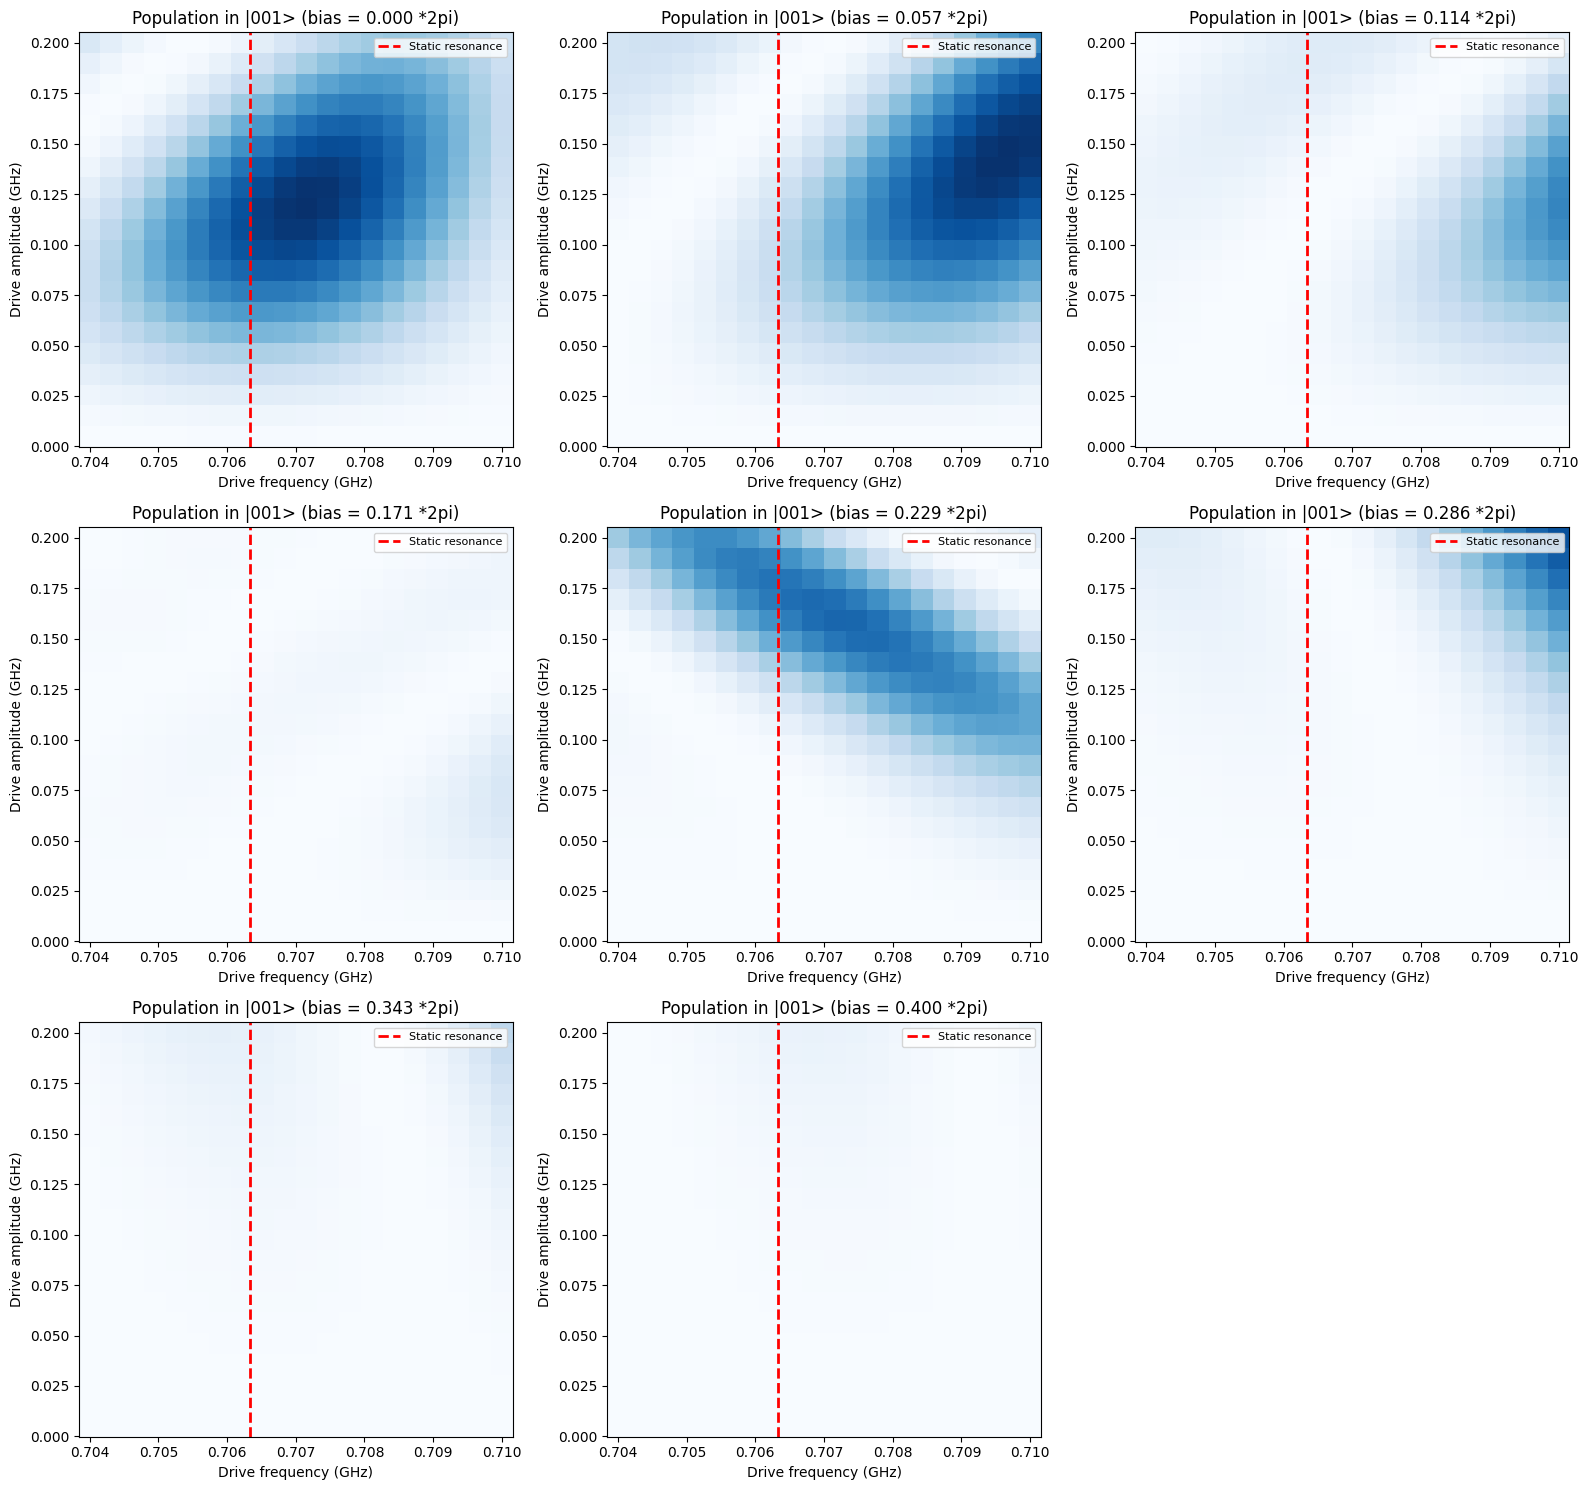

In [45]:
# Vergleich der Populationsdynamik für verschiedene bias-Werte
n_bias = len(final_pop_grids)

# Automatisches Grid-Layout berechnen
import math
ncols = math.ceil(math.sqrt(n_bias))
nrows = math.ceil(n_bias / ncols)

# Figsize mit extra Platz für Colorbar
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols + 1, 5*nrows), squeeze=False)
axes_flat = axes.flatten()

for idx, (bias_label, final_pop_grid) in enumerate(final_pop_grids.items()):
    ax = axes_flat[idx]
    
    pcm = ax.pcolormesh(
        mesh_wd / (2 * np.pi),
        mesh_A / (2 * np.pi),
        final_pop_grid,
        shading="auto",
        rasterized=True,
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    
    ax.axvline(x=static_resonant_frequency, color='red', linestyle='--', linewidth=2, label='Static resonance')
    
    ax.set_xlabel("Drive frequency (GHz)")
    ax.set_ylabel("Drive amplitude (GHz)")
    ax.set_title(f"Population in |001> (bias = {bias_label} *2pi)")
    ax.legend(loc='upper right', fontsize=8)

# Ungenutzte Subplots verbergen
for idx in range(n_bias, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Gemeinsamer Colorbar mit angepasstem Platz
# cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
# fig.colorbar(pcm, cax=cbar_ax, label="Population in |001>")

plt.subplots_adjust(right=0.9)
plt.tight_layout()
plt.show()


## Implementing the resonance condition

With the dressed-basis operators in hand, we can now apply the resonance-condition function introduced above.

Before solving for the resonant drive explicitly, we have performed a sweep over drive frequency and amplitude to map the population-transfer landscape. This gives a direct numerical reference for where the strongest transfer occurs.

We then use the resonance-condition function we built before to compute the predicted resonant frequency as a function of amplitude and compare that prediction against the sweep.
To do this, we first convert the `Qobj` object $V_{1,\mathrm{dressed}}$ into a NumPy array.

In [26]:
E_array = sorted_evals.reshape(dim_q1 * dim_c * dim_q2)
V_1_dressed_array = (
    V_1_dressed.full().reshape(dim_q1 * dim_c * dim_q2, dim_q1 * dim_c * dim_q2).real
)

We take $r=2$ and compute our prediction of the amplitude-dependent resonant drive frequencies

In [ ]:
lresonant_wd_order2 = np.zeros_like(lA, dtype=float)
wd_initial_guess = static_resonant_frequency

for j, A in enumerate(tqdm(lA)):
    # sucht nach Nullstelle
    resonant_wd_solution= fsolve(
        resonant_condition, wd_initial_guess,
        args=(A, 2, state_a, state_b, E_array, None, V_1_dressed_array),
    )

    lresonant_wd_order2[j] = float(resonant_wd_solution[0])
    wd_initial_guess = lresonant_wd_order2[j]

  0%|          | 0/20 [00:00<?, ?it/s]

We compare the theoretical predictions with the numerical reference.

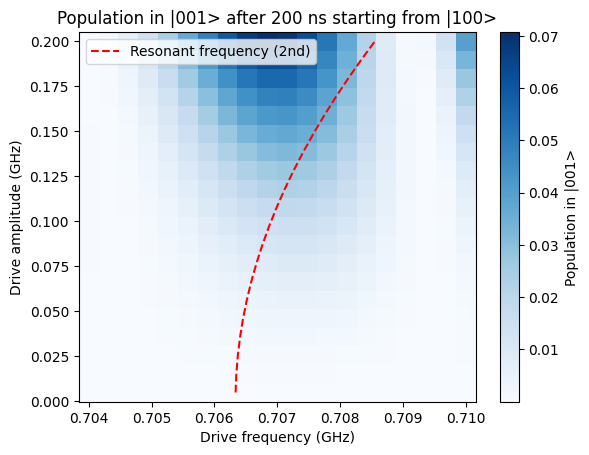

In [47]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    mesh_wd / (2 * np.pi),
    mesh_A / (2 * np.pi),
    final_pop_grid,
    shading="auto",
    rasterized=True,
    cmap="Blues",
)
fig.colorbar(pcm, ax=ax, label="Population in |001>")
ax.plot(
    lresonant_wd_order2 / (2 * np.pi),
    lA / (2 * np.pi),
    ls="--",
    color="red",
    label="Resonant frequency (2nd)",
)
ax.set_xlabel("Drive frequency (GHz)")
ax.set_ylabel("Drive amplitude (GHz)")
ax.set_title("Population in |001> after 200 ns starting from |100>")
ax.legend()

We see that implementing the resonance condition helps us to determine the drive frequency even at high drive amplitudes.

## Population Transfer Rate

Having determined the amplitude-dependent drive frequency in the previous section, we can now use it to estimate the Rabi rate. As we want to stop the drive at the point of maximal population transfer (to obtain an iSWAP gate), we want to have very precise predictions of the Rabi rate. As we compute the Rabi rate pertrubatively to order $r$, it is expected that higher orders can give more precise predictions. Let us test numerically, how high we should in perturbation order.

We take $r=2$ and compute our prediction of the Rabi rate, using our previoulsy defined funtion:

In [48]:
lresonant_rabi_order2 = np.zeros_like(lA)

for index in range(len(lA)):
    wd = lresonant_wd_order2[index]
    amp = lA[index]
    rabi = rabi_rate(wd, amp, 2, E_array, None, V_1_dressed_array)
    lresonant_rabi_order2[index] = np.abs(rabi)

Using the resonant frequencies predicted by second-order perturbation theory, we numerically compute the final population at the end of the evolution.

If the perturbative description is accurate, the population predicted from the Rabi oscillation (using the perturbative Rabi rate) should agree with the numerical simulation.

In [49]:
# Evolution along the resonant frequency and drive amplitude
lpop_resonant = np.zeros_like(lA)

tlist = np.linspace(0, 200, 1000)
for i in tqdm(range(len(lA))):
    amp = lA[i]
    fre = lresonant_wd_order2[i]
    result = mesolve(
        [H_0_num, [V_1_num, lambda t, args: amp * np.cos(fre * t)]],
        sorted_evecs[1, 0, 0],
        tlist,
        [],
        e_ops=[projection_001],
    )
    lpop_resonant[i] = result.expect[0][-1]

  0%|          | 0/20 [00:00<?, ?it/s]

With resonant states in the effective Hamiltonian, time evolution in the effective Hamiltonian is
$$
P = \sin^2(\Omega_{ab} t)
$$

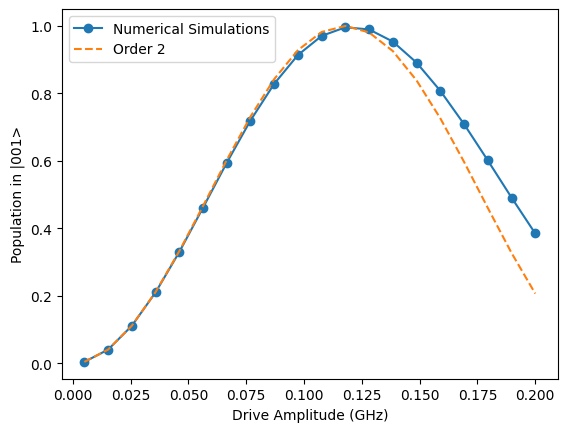

In [50]:
fig, ax = plt.subplots()
ax.plot(lA / (2 * np.pi), lpop_resonant, marker="o", label="Numerical Simulations")
ax.plot(
    lA / (2 * np.pi),
    np.sin(np.array(lresonant_rabi_order2) * tlist[-1]) ** 2,
    linestyle="--",
    label="Order 2",
)
ax.set_xlabel("Drive Amplitude (GHz)")
ax.set_ylabel("Population in |001>")
ax.legend()

Can we mitigate the errros in large amplitudes by going to higher order?

(Due to the long computing time in higher orders, we may directly import pre-computed values from saved dataset.)

In [51]:
ds = xr.open_dataset("resonant_frequency_and_rabi_rate.nc")
lresonant_wd_order3 = ds["resonant_frequency_order_3"].values
lresonant_wd_order4 = ds["resonant_frequency_order_4"].values
lresonant_rabi_order3 = ds["rabi_rate_order_3"].values
lresonant_rabi_order4 = ds["rabi_rate_order_4"].values
ds.close()

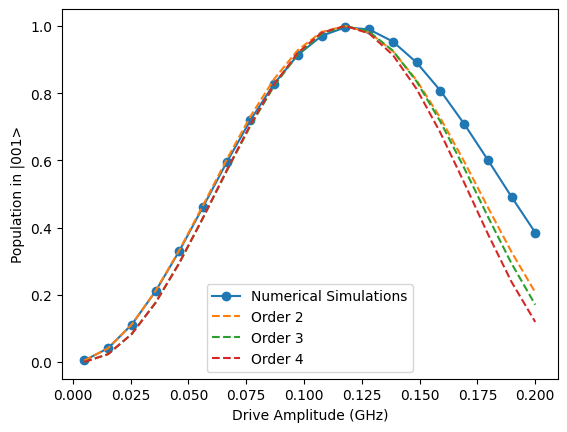

In [52]:
fig, ax = plt.subplots()
ax.plot(lA / (2 * np.pi), lpop_resonant, marker="o", label="Numerical Simulations")
ax.plot(
    lA / (2 * np.pi),
    np.sin(np.array(lresonant_rabi_order2) * tlist[-1]) ** 2,
    linestyle="--",
    label="Order 2",
)
ax.plot(
    lA / (2 * np.pi),
    np.sin(np.array(lresonant_rabi_order3) * tlist[-1]) ** 2,
    linestyle="--",
    label="Order 3",
)
ax.plot(
    lA / (2 * np.pi),
    np.sin(np.array(lresonant_rabi_order4) * tlist[-1]) ** 2,
    linestyle="--",
    label="Order 4",
)
ax.set_xlabel("Drive Amplitude (GHz)")
ax.set_ylabel("Population in |001>")
ax.legend()

# Improving the Fidelities

The solution to the conundrum in the last section is the large leakage to $|010\rangle$ state when going to higher amplitudes. This is ultimately tied to the topic of **Fast Oscillations**.

## Addressing Fast Oscillations

Now we test for the maximal drive amplitude and see the real-time evolutions to figure out what causes the imperfect predictions of the rabi rate.

In [53]:
test_fre = lresonant_wd_order2[-1]
test_amp = lA[-1]

test_tlist = np.arange(0, 250, 0.01)
test_dynamics = mesolve(
    [H_0_num, [V_1_num, lambda t, args: test_amp * np.cos(test_fre * t)]],
    sorted_evecs[1, 0, 0],
    test_tlist,
    [],
    e_ops=[projection_001, projection_100, projection_010, projection_111],
    options={"progress_bar": "tqdm"},
)

  0%|          | 0/24999 [00:00<?, ?it/s]

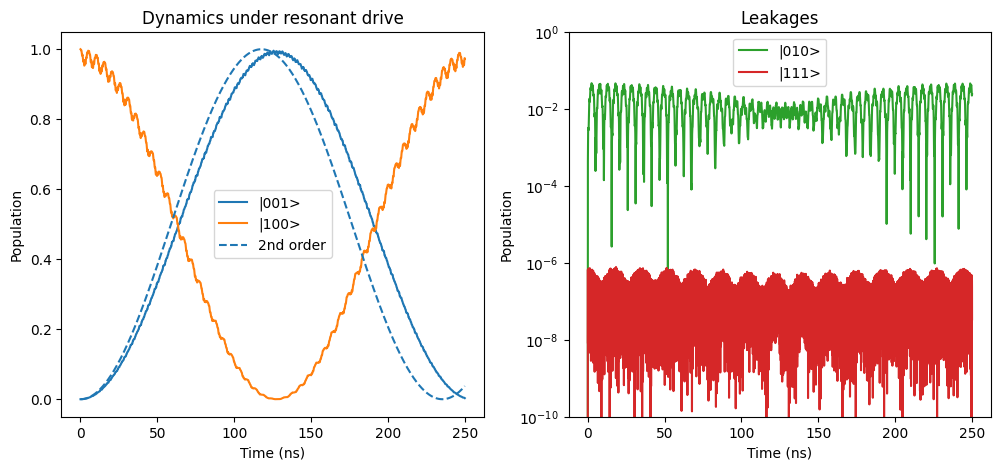

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(test_tlist, test_dynamics.expect[0], label="|001>")
ax[0].plot(test_tlist, test_dynamics.expect[1], label="|100>")
ax[0].plot(
    test_tlist,
    np.sin(np.array(lresonant_rabi_order2[-1]) * test_tlist) ** 2,
    ls="--",
    label="2nd order",
    color="C0",
)
ax[0].set_xlabel("Time (ns)")
ax[0].set_ylabel("Population")
ax[0].set_title("Dynamics under resonant drive")
ax[0].legend()

ax[1].plot(test_tlist, test_dynamics.expect[2], label="|010>", color="C2")
ax[1].plot(test_tlist, test_dynamics.expect[3], label="|111>", color="C3")
ax[1].set_ylim(1e-10, 1)
ax[1].set_xlabel("Time (ns)")
ax[1].set_ylabel("Population")
ax[1].set_title("Leakages")
ax[1].set_yscale("log")
ax[1].legend()

In the plot, we saw that the predictions from pure Rabi oscillations (dashed line) deviate from real population transfer (solid lines).

Apart from that, there are two key observations in the figure:

- In the population of $|100\rangle$, there are a lot of wiggles during the time. This can be understood as an anology to the counter-rotating terms in the rotating wave approximations. However, we did not apply the rotating wave approximaton, so these fast oscillations results from hybridizations of intermediate states participating in the eigenstates in Sambe representations.
- In the states not in the computational subspace, there is a large population in the coupler, which is the $|010\rangle$ state. To include the non-negligable population, we need to include the third state to enlarge the degenerate subspace. i.e.,
$$ H_{\text{eff}} =
\begin{array}{c}
|001\rangle \\
|100\rangle \\
|010\rangle
\end{array}
\begin{bmatrix}
\delta_a & \Omega_{ab} & \Omega_{ac} \\
\Omega_{ab}^* & \delta_b & \Omega_{bc} \\
\Omega_{ab}^* & \Omega_{bc}^* & \delta_c \\
\end{bmatrix}
$$

In [55]:
initial_state = np.zeros(dim_q1 * dim_c * dim_q2)
initial_state[state_a] = 1

state_c = dim_q2  # state |010>

We now use built-on function "Psi_t_FloquetPertub" for computing the dynamics predicted in perturbation theory.

[**Exercise**: Please find correct resonant condition of state_c that passes into "Psi_t_FloquetPertub" function.]

In [56]:
rH = 2
rW = 0
psi_t_rHeff2_rW0 = Psi_t_FloquetPerturb(
    rH,
    rW,
    test_fre,
    test_amp,
    {state_a:1, state_b:0, state_c:2}, # E_state_a - wd = E_state_b = E_state_c - 2*wd
    E_array,
    V_1_dressed_array,
    initial_state,
    test_tlist,
)

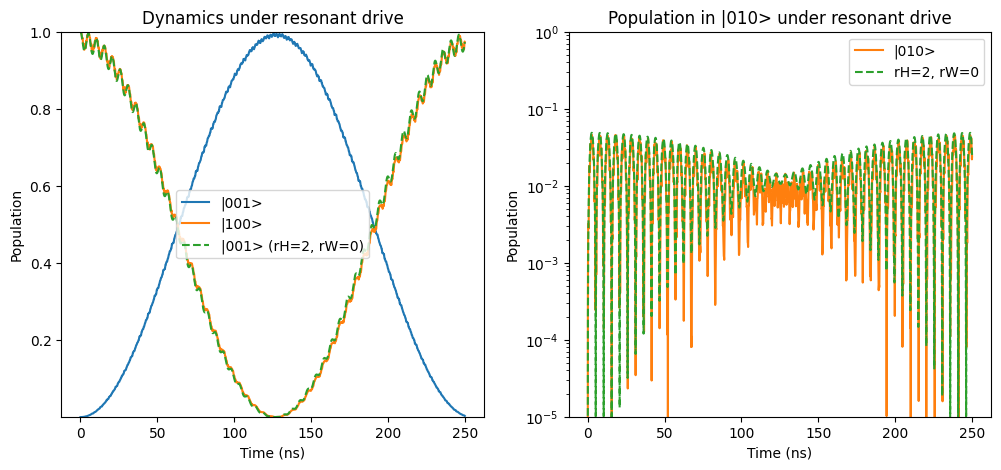

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(test_tlist, test_dynamics.expect[0], label="|001>")
ax[0].plot(test_tlist, test_dynamics.expect[1], label="|100>")
ax[0].plot(
    test_tlist,
    np.abs(psi_t_rHeff2_rW0[state_a, :]) ** 2,
    "--",
    label="|001> (rH=2, rW=0)",
)
ax[0].set_xlabel("Time (ns)")
ax[0].set_ylabel("Population")
ax[0].set_title("Dynamics under resonant drive")
ax[0].legend()
ax[0].set_ylim(1e-3, 1)

ax[1].plot(test_tlist, test_dynamics.expect[2], label="|010>", color="C1")
ax[1].plot(
    test_tlist,
    np.abs(psi_t_rHeff2_rW0[state_c, :]) ** 2,
    "--",
    label="rH=2, rW=0",
    color="C2",
)
ax[1].set_ylim(1e-5, 1)
ax[1].set_xlabel("Time (ns)")
ax[1].set_ylabel("Population")
ax[1].set_title("Population in |010> under resonant drive")
ax[1].set_yscale("log")
ax[1].legend()

[**Bonus**: You may try to change rW to see how prediced dynamics changes. Why would large rW help?]

By seeing the fast oscillations are captured by including the third state, we now again sweep the drive amplitude in lA to see if the populations in the end of the time are correctly captured.

In [58]:
lpop_order2 = np.zeros_like(lA)

for i in tqdm(range(len(lA))):
    amp = lA[i]
    fre = lresonant_wd_order2[i]
    psi_t = Psi_t_FloquetPerturb(
        2,
        0,
        fre,
        amp,
        {state_a: 1, state_b: 0, state_c: 2},  # E_state_a - wd = E_state_b
        E_array,
        V_1_dressed_array,
        initial_state,
        tlist,
    )
    lpop_order2[i] = np.abs(psi_t[state_b, -1]) ** 2

  0%|          | 0/20 [00:00<?, ?it/s]

We now benchmark effective models with different choices of states in the degenerate subspace. We use the following notation:
- 2-LS: effective model containing the computational states $|001\rangle$ and $|100\rangle$
- 3-LS: effective model containing $|001\rangle$, $|100\rangle$, and the leakage state $|010\rangle$

Throughout this comparison, full numerical simulation is used as the reference.

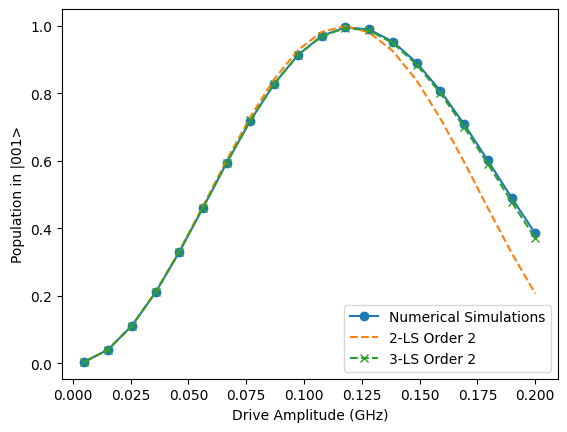

In [59]:
fig, ax = plt.subplots()
ax.plot(lA / (2 * np.pi), lpop_resonant, marker="o", label="Numerical Simulations")
ax.plot(
    lA / (2 * np.pi),
    np.sin(np.array(lresonant_rabi_order2) * tlist[-1]) ** 2,
    linestyle="--",
    label="2-LS Order 2",
)
ax.plot(
    lA / (2 * np.pi),
    lpop_order2,
    marker="x",
    linestyle="--",
    label="3-LS Order 2",
)
ax.set_xlabel("Drive Amplitude (GHz)")
ax.set_ylabel("Population in |001>")
ax.legend()

## Analysing the improved Gate Fidelities

The analytical model predicts both the time evolution and the leakage dynamics well. We now compute the full time evolution directly for comparison.

Using the resonant frequencies predicted by second-order perturbation theory, we need take the fast oscillation into account and extract the gate time for the iSWAP interaction. The way of finding correct pulse length relies on the propator $U$. At each time, we can compute the propagator $U$ from three states involved and evaluate corresponding fidelity with respect to the ideal evolution $U_{\text{ideal}}$:
$$
\text{Fidelity} = \frac{\left|\mathrm{Tr}\left(U_{\text{ideal}}^{\dagger} U\right)\right|^2}{d^2}.
$$
with
$$
U_{\text{ideal}} =
\begin{bmatrix}
0 & i & 0 \\
i & 0 & 0 \\
0 & 0 & 1 \\
\end{bmatrix}
$$
With this in hand, the pulse length is determined by maximal fidelity one can achieve during the time evoluitons.

We use perturbation theory to first find optimal fidelity at second order perturbation theory.

With the optimal times identified from perturbation theory, we now perform full numerical simulations to compute the exact system evolution and extract the unitary propagator $U(t)$ for each amplitude. This allows us to evaluate the true fidelity without perturbative approximations.

For computational efficiency, we exploit the structure of the problem: rather than evolving the full system, we evolve each of the three computational states separately and stack their final amplitudes to form the 3×3 unitary matrix $U$ restricted to the relevant subspace. The gate fidelity is then computed as:
$$
\text{Fidelity} = \frac{\left|\mathrm{Tr}\left(U_{\text{ideal}}^{\dagger} U\right)\right|^2}{d^2}
$$
where $d=3$ is the dimension of the subspace and $U_{\text{ideal}}$ is the target iSWAP unitary. This comparison reveals the discrepancy between the perturbative predictions and the true dynamics.

In [60]:
lfidelity_optimal_numerical = np.zeros_like(lA)
lU_optimal_numerical = np.zeros((len(lA), 3, 3), dtype=complex)

# Define ideal iSWAP gate for comparison
U_ideal = np.array([[0, 1j, 0], [1j, 0, 0], [0, 0, 1]], dtype=complex)

for i in tqdm(range(len(lA))):
    fre = lresonant_wd_order2[i]
    amp = lA[i]

    tlist = np.arange(0, lt_optimal_prediction[i], 0.01)

    # Instead of computing full propagator, evolve each basis state separately
    # This is much faster for extracting just the 3x3 subsystem
    subsystem_indices = [state_a, state_b, state_c]
    U_subsystem = np.zeros((3, 3), dtype=complex)

    for col_idx, initial_state_idx in enumerate(subsystem_indices):
        # Create initial state |state_idx⟩
        initial_state = np.zeros(len(E_array))
        initial_state[initial_state_idx] = 1
        initial_state = Qobj(initial_state, dims=[[dim_q1, dim_c, dim_q2], [1]])

        # Evolve using mesolve
        result = mesolve(
            [H_0_dressed, [V_1_dressed, lambda t, args: amp * np.cos(fre * t)]],
            initial_state,
            tlist,
            [],
        )
        final_state = result.states[-1]

        # Extract subsystem components to form column of unitary
        for row_idx, j_state in enumerate(subsystem_indices):
            U_subsystem[row_idx, col_idx] = final_state.full()[j_state, 0]

    lU_optimal_numerical[i] = U_subsystem

    # Compute gate fidelity: F = |Tr(U_ideal† U_subsystem)|² / 3²
    trace_overlap = np.trace(U_ideal.conj().T @ U_subsystem)
    lfidelity_optimal_numerical[i] = np.abs(trace_overlap) ** 2 / 3**2

  0%|          | 0/20 [00:00<?, ?it/s]

NameError: name 'lt_optimal_prediction' is not defined

If computing takes too long, it's possible to import the values from pre-computed dataset

In [ ]:
ds = xr.open_dataset("resonant_frequency_and_rabi_rate.nc")
lA = ds["drive_amplitude"].values
lt_optimal_prediction = ds["optimal_time_prediction"].values
lfidelity_optimal_numerical = ds["optimal_fidelity_numerical"].values
lU_optimal_numerical = ds["optimal_U_numerical"].values
ds.close()

To understand the sources of infidelity, we decompose the total error into two components: **leakage error** and **remaining error**. Leakage occurs when the quantum state escapes the computational subspace spanned by $|001\rangle$ and $|100\rangle$ into the third state such as $|010\rangle$.

For each unitary $U$ obtained from the numerical evolution, the leakage error is quantified by the loss of probability density in the computational 2×2 block:
$$
\text{Leakage} = 1 - \frac{\mathrm{Tr}(U_{\text{comp}}^{\dagger} U_{\text{comp}})}{2}
$$
where $U_{\text{comp}}$ is the $2 \times 2$ restriction of $U$ to the computational subspace. The remaining error is attributed to phase shifts and incomplete rotation within the computational subspace.

In [ ]:
lleakage_error_numerical = np.zeros_like(lA)

for i in tqdm(range(len(lA))):
    U = lU_optimal_numerical[i]
    leakage_numerical = 1 - np.real(np.trace(U[:2, :2].conj().T @ U[:2, :2])) / 2
    lleakage_error_numerical[i] = leakage_numerical

In [ ]:
# compare the optimal predictions with numerical simulations
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(
    lA / (2 * np.pi),
    1 - lfidelity_optimal_numerical,
    "o-",
    label="Total Error",
    color="C0",
)
ax.plot(
    lA / (2 * np.pi), lleakage_error_numerical, "o--", label="Leakage Error", color="C0"
)
ax.set_xlabel("Drive Amplitude (GHz)")
ax.set_ylabel("Total Error")
ax.set_title("Analysis of Errors")
ax.set_yscale("log")
ax.legend()

From this comparison, it is clear that leakage becomes dominant as the drive amplitude increases. To suppress this leakage and recover high fidelity, one can use optimized pulse shaping, such as DRAG pulses. Another important error source is phase accumulation during the pulse. Because the population transfer is not a perfect Rabi oscillation, an additional control degree of freedom—the drive phase—is needed to compensate these phase errors.

Further explorative tasks:
- How to further improve the fidelities?
- Leakages in other states, i.e., $|000\rangle$ and $|101\rangle$
- Extending to bSWAP gate, i.e., $|000\rangle \leftrightarrow |101\rangle$ or C-Phase gate, i.e., $|101\rangle \leftrightarrow |200\rangle$.

# Save Data

In [ ]:
ds = xr.Dataset(
    {
        "resonant_frequency_order_2": (("drive_amplitude"), lresonant_wd_order3),
        "resonant_frequency_order_3": (("drive_amplitude"), lresonant_wd_order3),
        "resonant_frequency_order_4": (("drive_amplitude"), lresonant_wd_order4),
        "rabi_rate_order_2": (("drive_amplitude"), lresonant_rabi_order2),
        "rabi_rate_order_3": (("drive_amplitude"), lresonant_rabi_order3),
        "rabi_rate_order_4": (("drive_amplitude"), lresonant_rabi_order4),
        "optimal_time_prediction": (("drive_amplitude"), lt_optimal_prediction),
        "optimal_fidelity_prediction": (
            ("drive_amplitude"),
            lfidelity_optimal_prediction,
        ),
        "optimal_U_prediction": (
            ("drive_amplitude", "subspace_row", "subspace_col"),
            lU_optimal_prediction,
        ),
        "optimal_fidelity_numerical": (
            ("drive_amplitude"),
            lfidelity_optimal_numerical,
        ),
        "optimal_U_numerical": (
            ("drive_amplitude", "subspace_row", "subspace_col"),
            lU_optimal_numerical,
        ),
    },
    coords={
        "drive_amplitude": lA,
        "subspace_row": np.arange(3),
        "subspace_col": np.arange(3),
    },
)
ds.to_netcdf("resonant_frequency_and_rabi_rate.nc", auto_complex=True)

In [ ]:
order = 3
lresonant_wd_order3 = np.zeros_like(lA)
lresonant_rabi_order3 = np.zeros_like(lA)

for j, A in enumerate(tqdm(lA)):
    wd_initial_guess = 2 * np.pi * 0.705
    resonant_wd_solution = fsolve(
        resonant_condition,
        wd_initial_guess,
        args=(A, order, state_a, state_b, E_array, None, V_1_dressed_array),
    )
    lresonant_wd_order3[j] = resonant_wd_solution[0]

    rabi = rabi_rate(
        resonant_wd_solution[0],
        A,
        order,
        state_b,
        state_a,
        E_array,
        V0=None,
        V1=V_1_dressed_array,
    )
    lresonant_rabi_order3[j] = np.abs(rabi)

In [ ]:
order = 4
lresonant_wd_order4 = np.zeros_like(lA)
lresonant_rabi_order4 = np.zeros_like(lA)

for j, A in enumerate(tqdm(lA)):
    wd_initial_guess = 2 * np.pi * 0.705
    resonant_wd_solution = fsolve(
        resonant_condition,
        wd_initial_guess,
        args=(A, order, state_a, state_b, E_array, None, V_1_dressed_array),
    )
    lresonant_wd_order4[j] = resonant_wd_solution[0]

    rabi = rabi_rate(
        resonant_wd_solution[0],
        A,
        order,
        state_b,
        state_a,
        E_array,
        V0=None,
        V1=V_1_dressed_array,
    )
    lresonant_rabi_order4[j] = np.abs(rabi)

In [ ]:
lleakage1 = np.zeros_like(lA)
lleakage2 = np.zeros_like(lA)

for i in tqdm(range(len(lA))):
    fre = lresonant_wd_order2[i]
    amp = lA[i]

    matrix = Heff_Floquet_matrix_summed(
        2,
        fre,
        {state_a: 1, state_b: 0, state_c: 2},
        E_num,
        amp / 2 * V1_num,
        V0=None,
    )
    lleakage1[i] = np.abs(matrix[0, 2])
    lleakage2[i] = np.abs(matrix[1, 2])

In [ ]:
fig, ax = plt.subplots()
ax.plot(lA / (2 * np.pi), lleakage1, label="Leakage to |010> from |001>")
ax.plot(lA / (2 * np.pi), lleakage2, label="Leakage to |010> from |100>")
ax.set_xlabel("Drive Amplitude (GHz)")
ax.set_ylabel("Leakage Matrix Element")
ax.legend()